## Importancia de variables
Para analizar este tema, usaremos los datos del número de bicicletas rentadas en Washington para diversos días. El objetivo es predecir cuantas bicicletas en total se rentarán cada día, usando la información temporal (fecha) y de condiciones climáticas de cada día.

Diccionario: http://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset

Nótese que incluyendo tendencias y otras medidas, se podría analizar este problema como un problema de series de tiempo en lugar de regresión.

In [1]:
import pandas as pd
data = pd.read_csv('day.csv')

<AxesSubplot:>

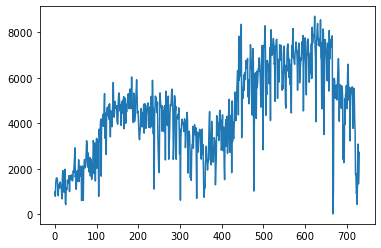

In [3]:
import matplotlib.pyplot as plt
plt.figure
data['cnt'][:].plot()


In [4]:
data

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


Para este ejemplo, nos quedaremos solo con el siguiente subconjunto de variables:

In [5]:
data = data[['season', 'yr','mnth', 'weekday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']]
data.head()

,season,yr,mnth,weekday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,6,2,0.344167,0.363625,0.805833,0.160446,985
1,1,0,1,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,0,1,2,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,0,1,3,1,0.226957,0.229270,0.436957,0.186900,1600


Note que, según el diccionario, la variable weathersit es de tipo categorica, al igual que season. Por esta razón, las llevaré a valores dummies (one-hot encoding), para así poderles calcular la correlación de mejor forma.

In [20]:
data2 = pd.get_dummies(data, columns=['season', 'weathersit'])
data2

,yr,mnth,weekday,temp,atemp,hum,windspeed,cnt,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
0,0,1,6,0.344167,0.363625,0.805833,0.160446,985,1,0,0,0,0,1,0
1,0,1,0,0.363478,0.353739,0.696087,0.248539,801,1,0,0,0,0,1,0
2,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,1,0,0,0,1,0,0
3,0,1,2,0.200000,0.212122,0.590435,0.160296,1562,1,0,0,0,1,0,0
4,0,1,3,0.226957,0.229270,0.436957,0.186900,1600,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,12,4,0.254167,0.226642,0.652917,0.350133,2114,1,0,0,0,0,1,0
727,1,12,5,0.253333,0.255046,0.590000,0.155471,3095,1,0,0,0,0,1,0
728,1,12,6,0.253333,0.242400,0.752917,0.124383,1341,1,0,0,0,0,1,0
729,1,12,0,0.255833,0.231700,0.483333,0.350754,1796,1,0,0,0,1,0,0


Ahora sí, ya tengo listo mi dataset para comenzar a analizar las importancias de las variables.

Vamos a ver varias formas de detectar esta importancia de las variables.

## Correlación clásica (Pearson)

Para esto, desde la parte de análisis descriptivo, se suele usar principalmente la correlación.

La forma más común de analizar dichas correlaciones es utilizar la matriz de correlación clásica de las variables (correlación de Pearson).

In [21]:
data2.corr()

,yr,mnth,weekday,temp,atemp,hum,windspeed,cnt,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
yr,1.000000,-0.001792,-0.005461,0.047604,0.046106,-0.110651,-0.011817,0.566710,0.002385,-0.000793,-0.000805,-0.000776,0.029429,-0.003869,-0.073941
mnth,-0.001792,1.000000,0.009509,0.220205,0.227459,0.222204,-0.207502,0.279977,-0.569733,-0.314015,0.199855,0.686954,-0.021960,-0.005365,0.078543
weekday,-0.005461,0.009509,1.000000,-0.000170,-0.007537,-0.052232,0.014282,0.067443,0.000783,-0.002355,0.010177,-0.008771,-0.029379,0.024074,0.016586
temp,0.047604,0.220205,-0.000170,1.000000,0.991702,0.126963,-0.157944,0.627494,-0.619800,0.155424,0.678471,-0.224793,0.116091,-0.097706,-0.058238
atemp,0.046106,0.227459,-0.007537,0.991702,1.000000,0.139988,-0.183643,0.631066,-0.625061,0.163661,0.655956,-0.204904,0.114951,-0.094253,-0.064727
hum,-0.110651,0.222204,-0.052232,0.126963,0.139988,1.000000,-0.248489,-0.100659,-0.181336,-0.003854,0.023101,0.162732,-0.575317,0.491834,0.267011
windspeed,-0.011817,-0.207502,0.014282,-0.157944,-0.183643,-0.248489,1.000000,-0.234545,0.178154,0.097513,-0.139732,-0.135466,-0.003964,-0.037408,0.117362
cnt,0.566710,0.279977,0.067443,0.627494,0.631066,-0.100659,-0.234545,1.000000,-0.563094,0.146197,0.346487,0.065593,0.252870,-0.172879,-0.239958
season_1,0.002385,-0.569733,0.000783,-0.619800,-0.625061,-0.181336,0.178154,-0.563094,1.000000,-0.332716,-0.337549,-0.325466,-0.023951,0.032441,-0.022764
season_2,-0.000793,-0.314015,-0.002355,0.155424,0.163661,-0.003854,0.097513,0.146197,-0.332716,1.000000,-0.341267,-0.329051,-0.023167,0.038836,-0.043136


<AxesSubplot:>

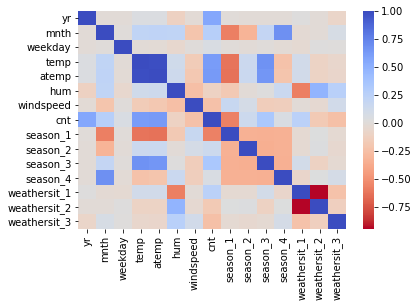

In [22]:
### Verla como heatmap
import seaborn as sns
# calculate the correlation matrix
corr = data2.corr()

# plot the heatmap
sns.heatmap(corr, 
        xticklabels=corr.columns,
        yticklabels=corr.columns, cmap='coolwarm_r')

De esta matriz de correlación notamos varios factores que van con la lógica: a mayor temperatura, más prestamos de bicicleta (con el frio nadie quiere salir en bicicleta); y también según la estación depende el número de bicicletas arrendadas. También por ejemplo en el segundo año del dataset aumentaron los préstamos de bicicletas (tendencia). 
La velocidad del viento (Windspeed) tiene correlación negativa con los prestamos.

Hay algunas variables que no se pueden capturar bien con esta correlación básica lineal: por ejemplo, el mes del año (piense en las estaciones: invierno suele ser de noviembre a febrero, es decir meses 11, 12, 1 y 2. Una correlación lineal no puede capturar eso).

Tambien weekday no la logra detectar bien: el problem con esta variable es que el primer dia de la semana en estos datos es el domingo (0), y el último es el sábado (6). Pensemos: ¿por que con nuestra correlación lineal esto es un problema?


### Correlación robusta (Spearman)

https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient (ver imágenes de ejemplo).

Resuelve el problema de la no linealidad, pero debe ser monótona la relación. También resuelve el problema de los outliers al ser robusta.


Ejercicio: Calcule las correlaciones de spearman y grafiquela como mapas de calor, tal como en el punto anterior.



In [23]:
### Ejercicio:

Las dos gráficas son muy parecidas en este caso, esto probablemente indique que no hay muchos outliers claros en los datos. Nótese que la relación del mes del año  y la del día de la semana aún no se captura muy bien, ya que tampoco es monótona.

Sin embargo, las correlaciones claramente no son iguales (imprimir o mostrar las tablas de correlación y notar que son diferentes).

### Correlación parcial

Se puede usar para hallar las relaciones lineales entre cada par de variables, quitando el efecto de las demás.





In [24]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import numpy as np

feature_num = data2.shape[1]
feature_name = data2.columns
partial_corr_matrix = np.zeros((feature_num, feature_num))
for i in range(feature_num):
    x1 = data2.iloc[:, i]
    for j in range(feature_num):
        if i == j:
            partial_corr_matrix[i, j] = 1
        elif j < i:
            partial_corr_matrix[i, j] = partial_corr_matrix[j, i]
        else:
            x2 = data2.iloc[:, j]
            df_control = data2.drop(columns=[feature_name[i], feature_name[j]], axis=1)
            L = LinearRegression().fit(df_control, x1)
            Lx = L.predict(df_control)
            x1_prime = x1 - Lx
            
            L = LinearRegression().fit(df_control, x2)
            Lx = L.predict(df_control)
            x2_prime = x2 - Lx
            partial_corr_matrix[i, j] = pearsonr(x1_prime, x2_prime)[0]

In [25]:
corrp = pd.DataFrame(partial_corr_matrix, columns=corr.columns)
corrp

,yr,mnth,weekday,temp,atemp,hum,windspeed,cnt,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
0,1.000000,0.039902,-1.464918e-01,-5.670645e-02,-3.544572e-02,3.386515e-02,1.538845e-01,0.774273,2.416423e-03,3.898200e-03,-6.789517e-03,1.040732e-03,-0.000587,0.000921,0.001959
1,0.039902,1.000000,3.702600e-02,1.693658e-02,-1.024978e-02,8.742609e-02,-1.644773e-02,-0.041737,-5.452464e-03,-1.570264e-03,6.622590e-03,-3.202114e-03,-0.000277,-0.000340,0.000517
2,-0.146492,0.037026,1.000000e+00,2.964961e-02,-5.283457e-02,-6.211323e-02,1.929251e-02,0.176071,9.999746e-06,2.034334e-07,-1.751568e-05,-1.141062e-06,-0.000005,0.000003,-0.000019
3,-0.056706,0.016937,2.964961e-02,1.000000e+00,9.662649e-01,6.260096e-05,1.915490e-01,0.101756,5.046683e-06,8.338272e-06,-1.099892e-05,-7.597990e-07,-0.000016,-0.000017,-0.000037
4,-0.035446,-0.010250,-5.283457e-02,9.662649e-01,1.000000e+00,6.519917e-02,-1.660021e-01,0.036071,1.337468e-07,-8.230017e-06,1.607145e-05,-3.217499e-06,0.000024,-0.000020,0.000010
5,0.033865,0.087426,-6.211323e-02,6.260096e-05,6.519917e-02,1.000000e+00,-2.947553e-01,-0.151338,4.167757e-06,2.106624e-06,-3.673702e-06,-7.563501e-07,-0.000028,-0.000002,-0.000018
6,0.153885,-0.016448,1.929251e-02,1.915490e-01,-1.660021e-01,-2.947553e-01,1.000000e+00,-0.228727,-7.392779e-06,1.186979e-05,8.844189e-07,-1.943219e-06,-0.000006,0.000006,0.000007
7,0.774273,-0.041737,1.760713e-01,1.017563e-01,3.607113e-02,-1.513377e-01,-2.287265e-01,1.000000,-1.927642e-03,2.830794e-03,5.925052e-03,1.137191e-05,-0.000543,-0.000910,0.002122
8,0.002416,-0.005452,9.999746e-06,5.046683e-06,1.337468e-07,4.167757e-06,-7.392779e-06,-0.001928,1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.999960,-0.999889,-0.999975
9,0.003898,-0.001570,2.034334e-07,8.338272e-06,-8.230017e-06,2.106624e-06,1.186979e-05,0.002831,-1.000000e+00,1.000000e+00,-1.000000e+00,-1.000000e+00,0.999935,-0.999737,-0.999972


<AxesSubplot:>

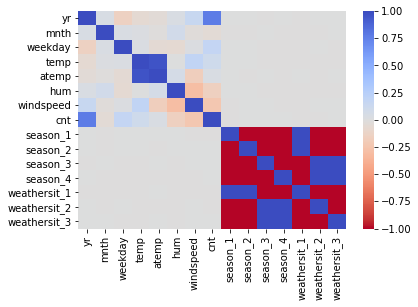

In [26]:
### Verla como heatmap
import seaborn as sns

# plot the heatmap
sns.heatmap(corrp, 
        xticklabels=corr.columns,
        yticklabels=corr.columns, cmap='coolwarm_r')

Este análisis de la correlación parcial nos dice: qué tanto influye una variable pos si sola a los préstamos de bicicletas (es decir, quitando los efectos de todas las demás variables).

Note por ejemplo que aquí vemos que lo que más influye en el préstamo de bicicletas es el año.
Y aquí con esta correlación parcial se ve cuáles las variables climáticas son las que realmente afectan los préstamos. 

Además, la correlación parcial es también muy útil para detectar que variables pueden descartarse o quitarse del modelo para simplificarlo. Por ejemplo, note que la correlación parcial muestra valores nulos en los efectos de las variables de estación: esto es debido a que la variable de estación 4 por si sola no aporta nada nuevo al modelo si ya tenemos las otras 3 (piense por ejemplo: si ya sé que no estoy en estación 1, ni 2, ni 3, es obvio que estoy en la 4, por lo que tener esta columna extra no aporta nada nuevo; podría fácilmente descartar la variable de estación 4 siempre y cuando conserve las otras 3 variables).

### Importancia de variables usando árboles de decisión

Algunos métodos de machine learning tienen por dentro algunos cálculos que pueden representar de cierto modo la importancia de las variables. 

En específico, en los métodos basados en árboles de decisión, se calcula algo similar a una importancia de variables y dicha importancia se guarda como un atributo de sus modelos en sklearn ("feature_importances_").

Recordemos que en el ejemplo de clase que hicimos para ver cómo entrenaban los árboles de decisión, buscábamos cual era la variable que más reducía la entropía (que sería buscar la que más “ganancia” de información tenía al reducir la incertidumbre). 

Ahora, la "importancia de variables" calculada por dichos modelos de sklearn sería algo similar a esto, pero promediada a través de todos los splits de todos los árboles para ver cuáles son las variables que suelen ser más propensas a usarse por tener más ganancia. Así se logra saber qué tan importante fue cada variable en general para todo el modelo.


Por ejemplo, entrenemos un gradient boosting sobre nuestro conjunto de datos y analicemos sus importancias (mientras más alto este valor, mayor es la importancia):

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

salida = data2['cnt'] 
entradas = data2[['yr', 'mnth', 'weekday', 'temp', 'atemp', 'hum', 'windspeed', 
       'season_1', 'season_2', 'season_3', 'season_4', 'weathersit_1',
       'weathersit_2', 'weathersit_3']]
gb = GradientBoostingRegressor(random_state = 1, max_depth = 10).fit(entradas, salida)

Text(0.5, 0, 'Valor de Importancia')

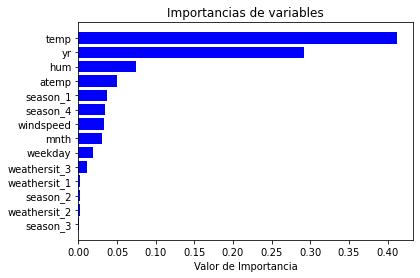

In [28]:
# Graficar importancias de cada una
features = entradas.columns
importances = gb.feature_importances_
indices = np.argsort(importances)

plt.figure()
plt.title('Importancias de variables')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Valor de Importancia')


Aquí se ven dos dominadores claros en la importancia de variables, los cuáles son la temperatura y el año, que son dos variables que se alinean con nuestro conocimiento de negocio (la gente decide si usar o no bicicletas según el clima, y también en el segundo año se volvió más popular el servicio).

Además, vemos algunas importancias intermedias como la humedad y la temperatura aparente, lo cual tiene también sentido porque cuando hay lluvias la gente no las usará.

Note que aquí se detecta que el mes sí tiene una importancia intermedia, algo que los demás métodos no capturaban tan bien: los árboles son capaces de detectar importancias aún cuando estas no tengan un comportamiento monótono (piense: un árbol de decisión puede tener por ejemplo ramas para meses menores a 3, otras ramas para meses entre 3 y 9, y otras para meses mayores o iguales a 10, capturando así relaciones no monótonas en los préstamos de bicicleta y que pueden deberse a la estación del año).

## SHAP values (valores SHAP)

Los valores de SHAP son tomados de la teoría de juegos (juegos cooperativos). En la teoría de juegos, estos valores son calculados en un juego cooperativo para poder determinar el impacto que cada uno de los jugadores está teniendo sobre el resultado final de dicho juego (ganar o perder).

Al llevarlos a nuestro caso de analítica de datos, los valores de Shapley serán calculados sobre nuestro conjunto de datos: para nosotros, cada una de las variables de entrada (características) serán cada uno de los "jugadores" de nuestro juego, y todos estos jugadores tendrán un cierto impacto (positivo o negativo) sobre el resultado final del "juego", dicho resultado final del juego será en nuestro caso la variable de salida de nuestro conjunto. Así, las variables de entrada influyen de distintas formas en la variable de salida, de forma análoga a como los jugadores influyen de distinta forma en el resultado final del juego.

Para calcular estos valores de Shap para nuestro conjunto de datos en Python, usaremos la librería SHAP (SHapley Additive Explanations), la cual está diseñada específicamente para esto (https://shap.readthedocs.io/en/latest/).

De esta forma, procedamos entonces a usar esta librería para analizar los valores de SHAP para nuestro ejemplo. Nótese que para crear estos valores se requiere tener un modelo ya entrenado, el cual será la entrada para el cálculo de los valores de SHAP de cada variable. Así, le suministraremos a la librería nuestro gradient boosting entrenado previamente.



In [29]:
# Correr esto una vez para instalar la libreria de SHAP en python (descomentar la linea y correrla)
# !pip install shap

In [30]:
import shap 

# Crear objeto explainer (explicador) de SHAP, con el gradient boosting usado anteriormente
explainer = shap.Explainer(gb)


# Calcular todos los valores de SHAP para nuestras entradas
shap_values = explainer(entradas)

Ahora, primero, observemos la media de los valores absolutos de SHAP en el conjunto de datos de todas las variables, que sería equivalente a mostrar la importancia de las variables para nuestro problema:

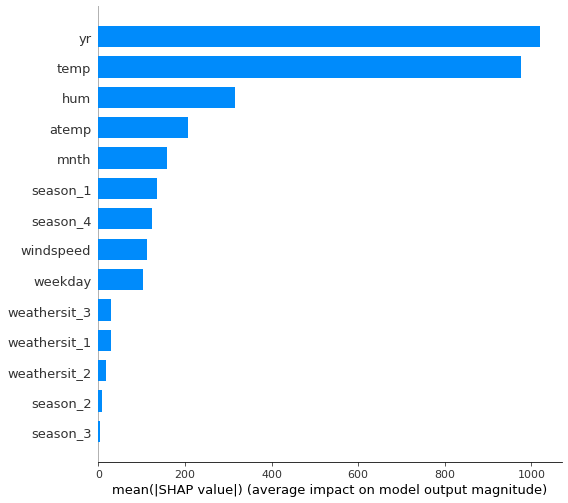

In [31]:
shap.summary_plot(shap_values, entradas, feature_names=features, plot_type="bar")

Vemos que según los valores de SHAP, la variable de mayor importancia en nuestro modelo es el año, lo cuál coincide con varios de los métodos anteriores. En segundo lugar aparece la temperatura, la cuál tiene también buen impacto en el modelo. Luego le siguen humedad y temperatura aparente, lo que tiene sentido porque sabemos que las variables climáticas pueden influir mucho. Por último, se ve el mes con un impacto también relativamente alto.

Note que este gráfico muestra una gran ventaja de los valores SHAP, y es que las unidades de estos valores coinciden con las del problema modelado. En este caso, por ejemplo para año (yr), su valor promedio absoluto SHAP de prácticamente 1000, quiere decir que la variable año tiene un impacto promedio de alrededor 1000 bicicletas en las predicciones (esto querría decir aproximadamente que "1000" de las bicicletas predichas (o que se dejaron de predecir) fueron por causa de estar en uno u otro año). Piense por ejemplo la gran ventaja que esto puede tener en cualquier problema (por ejemplo, ver en qué tantos dólares se afecta el precio de un carro según si es automático o manual, o según su marca, o su color, etc).

Para más detalle, creemos un gráfico de enjambre (beeswarm plot, inspirado en las abejas), que nos muestra no solo la importancia absoluta de las variables sino la dirección (positiva o negativa) del impacto de cada uno en nuestros registros.

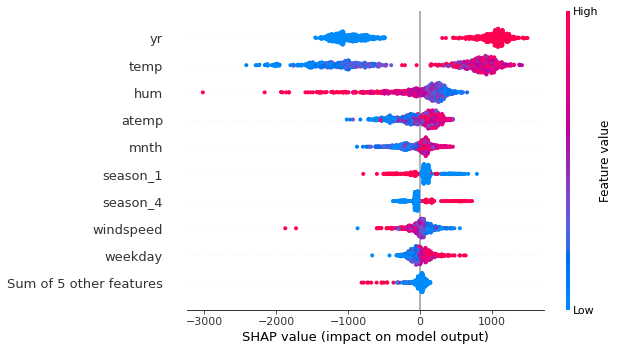

In [32]:
shap.plots.beeswarm(shap_values)

Notemos que aquí se nota la dirección en la que cada variable impacta al modelo. Claramente en el año, vemos cómo el año menor está relacionado con menos préstamos de bicicletas, y el año mayor es al contrario (se nota que aumentaron de un año al otro los préstamos). Por ejemplo en temperatura también se ve cómo menores temperaturas suelen estar relacionadas con menos préstamos y viceversa. Nótese por ejemplo también la de velocidad del viento (mientras más veloz el viento, menos bicicletas se prestaban), y la de humedad (a medida que había más humedad, se prestaban menos bicicletas).


Para profundizar, una ventaja adicional que tiene este método de valores SHAP es que se puede ver de forma individual para cada uno de los registros de nuestro conjunto. Esto resulta de suma importancia para añadirle explicabilidad a nuestro modelo, ya que podremos ver para cada individuo en específico, cómo cada una de sus variables contribuyo en su resultado (salida). 

Piense por ejemplo en un banco que aprueba o niega créditos a sus clientes: con los valores de SHAP, los clientes podrían saber las razones (variables) que llevaron a que les fuera aprobado o denegado su crédito, y así poder saber qué pueden hacer para intentarlo de nuevo en un futuro (si fueron rechazados).

Para nuestro ejemplo, usemos entonces estos valores de SHAP individuales para ver a detalle un par de días arbitrarios de nuestro conjunto y determinar cuáles fueron los factores que llevaron a qué en esos días específicos se prestarán más o menos bicicletas.

Usemos un gráfico de cascada (waterfall plot) para ver esa relación:

In [33]:
# Valores SHAP para el primer individuo de la base de datos (día 0, primer día del primer año)
individuo = 0
entradas[individuo:individuo+1] # Truco para ver fila con solo este individuo

,yr,mnth,weekday,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
0,0,1,6,0.344167,0.363625,0.805833,0.160446,1,0,0,0,0,1,0


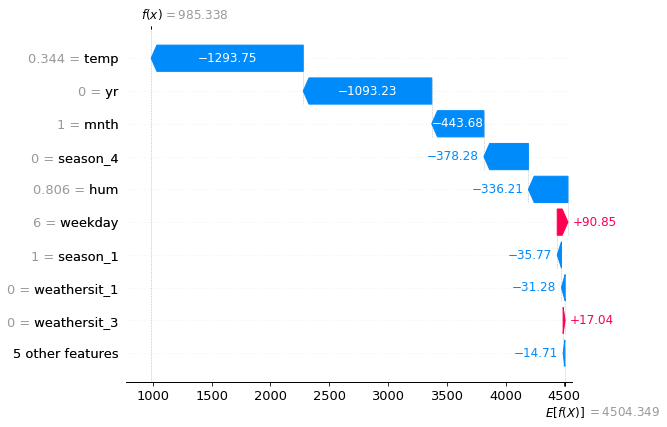

In [34]:
shap.plots.waterfall(shap_values[individuo])

Esta gráfica es bastante interesante ya que muestra muchas cosas de utilidad. Primero, abajo a la derecha se ve el valor esperado de la salida (de los préstamos de bicicleta), que sería de 4504.349 (el promedio de las salidas predichas por nuestro modelo).

In [35]:
salida.mean() #  Promedio de las salidas reales

4504.3488372093025

In [36]:
gb.predict(entradas).mean() # promedio de las salidas predichas por el modelo

4504.3488372093025

In [37]:
explainer.expected_value[0]  # El individuo base promedio del SHAP tiene el mismo valor


4504.3488372093025

Además, la gráfica lo que procede a mostrar es como, a partir de esa predicción base, cada variable tuvo su propio efecto y al final todos estos efectos se agregaron para generar la predicción final de 985 (de ahí el nombre "shapley ADDITIVE explanations).

Así, el hecho de estar en el año 0 reduce en 1293 las bicicletas, la temperatura lo reduce en 1093, el mes uno en 443, etc. Al agregar (sumar) todos estos valores SHAP al valor base promedio, se debe obtener un resultado equivalente a la predicción del modelo (985). Note además que el waterfall plot (diagrama de cascada) muestra en el tamaño de las flechas el impacto de cada variable sobre la predicción final).

In [38]:
# Realizar la adición: valor esperado (del invividuo promedio base) más los valores SHAP de nuestro individuo
explainer.expected_value[individuo] + sum(shap_values[individuo].values)

985.3383186326128

In [39]:
# Así, el valor del individuo promedio base de SHAP más sus valores SHAP debe dar equivalente
# a la predicción hecha por nuestro modelo
gb.predict(entradas)[individuo] # Debe dar equivalente al anterior

985.3383186326145

Miremos por último los valores de SHAP pero para otro día, esta vez un caso de verano del segundo año, donde esperaríamos más préstamos de bicicletas de lo habitual.

In [40]:
# Valores SHAP para un día del segundo año en verano
individuo =  542  #esto debe caer más o menos en el segundo año en verano
entradas[individuo:individuo+1] # Truco para ver fila con solo este individuo

,yr,mnth,weekday,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
542,1,6,2,0.630833,0.594704,0.373333,0.347642,0,0,1,0,1,0,0


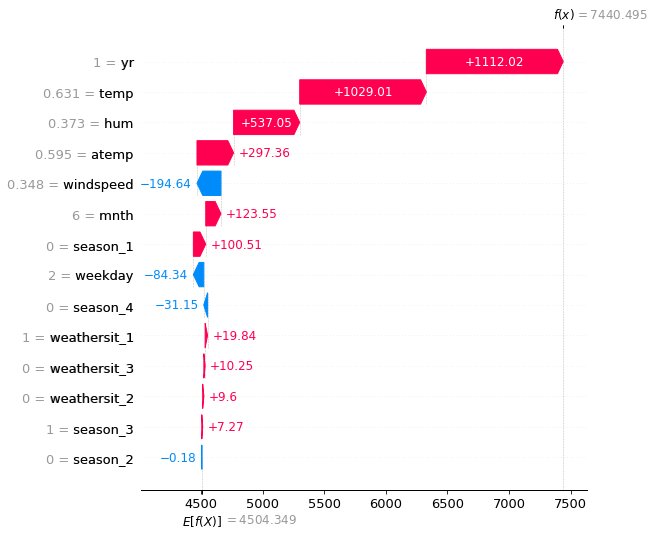

In [41]:
import matplotlib.pyplot as plt
shap.plots.waterfall(shap_values[individuo], max_display = 14, show=True)


En este caso, se nota como casi todas las variables (año, temperatura, humedad, etc) contribuyeron positivamente a aumentar el número de préstamos de bicicletas (que terminó siendo predicho de 7440 para ese día), mientras que solo un par de variables (el día de la semana de 2, NO estar en la estación 2 ni 4 y el viento) contribuyeron levemente de forma negativa a este.

Así, se ve que los valores de SHAP son de gran utilidad no solo para calcular la importancia de variables para un problema, sino también para poder añadirle explicabilidad a nuestro modelo y entender por qué realiza las predicciones que está realizando para cada individuo.

### Importancia de variables quitando cada variable

Este es un método muy usado para ver que tan importante es una variable en un modelo, es quitar dicha variable del modelo y ver cómo se comporta el modelo sin esa variable (si su rendimiento empeora mucho al quitarla, entonces la variable sí era muy importante para el modelo; de lo contrario, si no empeora mucho o mejora, la variable no era importante).

Este método funciona basándose en un hecho común de nuestra vida cotidiana:  a veces solo nos damos cuenta de cuán importante era algo en nuestra vida cuándo dejamos de tenerlo y vemos cómo nos afecta haberlo perdido (un amigo, una pareja, un familiar, algo material, etc.). 


#### Ejercicio

Para realizar este ejercicio, primero, cree un modelo base (por ejemplo, un árbol de decisión) y ajústelo sobre el conjunto total de datos y calcule su MAE.

Ahora, repita el ejercicio anterior una vez por cada variable de entrada. En cada repetición, debe dejar un dataframe que consista de todas las variables del conjunto EXCEPTO de dicha variable de entrada

Por ejemplo, primero repita todo el ejercicio quitando el año y dejando todas las demás, luego otro quitando la variable del mes y dejando todas las demás, etc.

Calcule el MAE para cada iteración del ejercicio.

Responda: ¿Cómo se comparan los MAE? ¿Cómo cree que estos valores de MAE entre las repeticiones ayuden a determinar cuál es la variable de mayor importancia? ¿Estos resultados se alinean con los demás métodos de importancia de variables?

Este mismo proceso se puede repetir con cualquier otro modelo más avanzado de inteligencia artificial (ver como se comportaría ese modelo sin cada una de las variables), lo cual lo hace muy útil para hallar importancias.

## Sobre la Selección de variables
Surge una duda con los métodos vistos anteriormente: todos estos sirven para ver qué tan importantes son las variables, ¿pero cómo se si son lo suficientemente importantes o no? Y, ¿Cómo sé cuáles de esas incluir y cuáles no en mi modelo final? Por ejemplo, si tengo 15 variables en total, ¿cómo sé si debo dejar solo las 5 más importantes, o las 10 más importantes, o las N más importantes?

La respuesta es que para esto se usan métodos de selección de variables, que utilizan por debajo varias de las técnicas de importancia de variables que hemos visto.

Por ejemplo, tenga en cuenta que el método anterior (el de quitar una variable para ver su importancia) se puede hacer de forma iterativa: en la primera iteración, quito la variable menos importante, y si en realidad no era importante dicha variable, se esperaría que el rendimiento del modelo mejore (o al menos que no empeore significativamente). Luego, en la segunda iteración, utilizo el conjunto de datos donde ya había quitado la primera más significativa y termino quitando la variable que en general era la segunda menos importante. 

Sigo así sucesivamente hasta que llegue al punto que desee (por ejemplo, itero hasta que llegue un punto donde, al quitar la siguiente variable, estoy empeorando significativamente las métricas en lugar de mejorarlas). A partir de aquí ya no vale la pena quitar más variables: así logré seleccionar variables para el modelo y dejar solo las suficientemente importantes. 

Esta forma iterativa del método se conoce como backward selection y se usa mucho en la parte de selección de variables para modelos de analítica. Existe también el método opuesto (empezar de cero e ir agregando una a una las variables, el cuál se llama forward selection. Incluso se pueden combinar ambos (bidirectional  selection). Todos estos métodos se engloban en la categoría de "stepwise selection".

El siguiente es el link de un ejemplo de backward selection para un caso en el que usan regresión lineal para estimar cuál debería ser el salario mínimo de cada país: https://towardsdatascience.com/stepwise-regression-tutorial-in-python-ebf7c782c922. Tener en cuenta que luego de cada iteración, la significancia de las variables restantes irá cambiando, ya que pueden volverse más o menos importantes en el subconjunto actual (pensar escenario de temperatura y temperatura aparente).

Sin embargo, hay que tener en cuenta que no siempre podemos guiarnos solo por la significancia estadística: puede que un cambio sobre un modelo haga que mejore solo levemente sus resultados y no sea estadísticamente significativo, pero este leve cambio según el caso que se esté abordando puede ser igualmente de gran importancia. Por ejemplo, si estuviéramos modelando un MAE como pérdidas en millones de dólares, y nuestro MAE pasa de 8.4 a 8.3, incluso si se obtuviera que no es significativo, es una mejora que igualmente sí quisieramos incluir en nuestro modelo.

Así, es también común usar las técnicas de stepwise selection no solo con significancia, sino comparando en cada paso si se mejoran o no las métricas de estos, tal como se muestra a continuación:

https://towardsdatascience.com/demystifying-r-squared-and-adjusted-r-squared-52903c006a60

## Otros comentarios generales

### Problemas donde la variable de salida no está predefinida (ejemplo: segmentar grupos de usuarios)
En estos casos, suele ser más difícil detectar variables "importantes", ya que no es tan claro "importantes para qué", como si lo es cuando buscamos que es lo que más afecta una salida. 

Aquí se puede considerar las variables de mayor variabilidad como importantes; o los grupos de variables que más correlación presenten entre si (ya que esos grupos de variables serán los que perfilarán los grupos). Una forma de hallarlas podría ser ejecutando un método de clustering, y luego un método de clasificación que prediga las etiquetas del cluster de cada dato, y vea cuáles variables son las más importantes para predecir dichas etiquetas.

### Importancia de variables categóricas

Existen también métodos estadísticos para determinar si una variable categórica influye o no en otra. Por ejemplo, uno de ellos se encuentra en este link:

https://machinelearningmastery.com/chi-squared-test-for-machine-learning/

Y aquí hay otro link que abarca más escenarios: https://towardsdatascience.com/levels-of-measurement-statistics-and-python-implementations-8ff8e7867d0b

### Multicolinealidad

Usualmente, nos enfocamos en revisar la correlación entre cada variable de entrada con la variable de salida.

Sin embargo, las variables explicativas que tengan una correlación muy alta entre sí, pueden traer un problema en algunos métodos de machine leanring, llamado multicolinealidad.

https://economipedia.com/definiciones/multicolinealidad.html#:~:text=La%20multicolinealidad%20es%20la%20relaci%C3%B3n,m%C3%A1s%20de%20dos%20variables%20explicativas.

En estos casos, se recomienda eliminar variables explicativas que tengan mucha relación con algunas otras del dataset, o que ya sean explicadas por el resto de las variables explicativas (en este caso, el ejemplo más claro sería la de temperatura aparente, que parece sobrar ya que ya se tiene temperatura).


### Y como siempre, no olvidar el conocimiento del negocio

A veces las mismas personas que ya conocen muy bien la problemática, nos pueden dar muy buenos insumos de cuáles son las variables más importantes para este. Esto nos podría servir incluso para ponderar el modelo para que le dé más importancia a ciertas variables.